<a href="https://colab.research.google.com/github/hazelkimhyejin/DEMO/blob/main/HAZELIPJIALING_Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.7 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="RjXxbafrEGCh3xKidMhQ")
project = rf.workspace("h-i-be7dk").project("object-detection-eynhl")
version = project.version(1)
dataset = version.download("yolov8")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Object-Detection-1 in yolov8:: 100%|██████████| 91/91 [00:00<00:00, 3424.14it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
/content/Object-Detection-1


In [4]:
from ultralytics import YOLO
import time

model = YOLO("yolo11n.pt")
start = time.time()
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="baseline"
)
print(f"Training time: {(time.time()-start)/60:.1f} min")

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Object-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline, nbs=64, nms=None, opset=None, 

In [5]:
metrics = model.val(data=f"{dataset.location}/data.yaml", split="test")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,587,807 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1145.3±524.2 MB/s, size: 50.1 KB)
val: Scanning /content/Object-Detection-1/test/labels... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 1.4Kit/s 0.0s
val: New cache created: /content/Object-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 12.1it/s 0.1s
                   all          3          3      0.361          1      0.774      0.708
black square tile with blue letter S          1          1       0.25          1      0.332      0.332
black square tile with green arrow          1          1        0.5          1      0.995      0.995
black square tile with white letter B          1          1      0.333          1      0.995      0.796
Speed: 0.4ms preprocess, 15

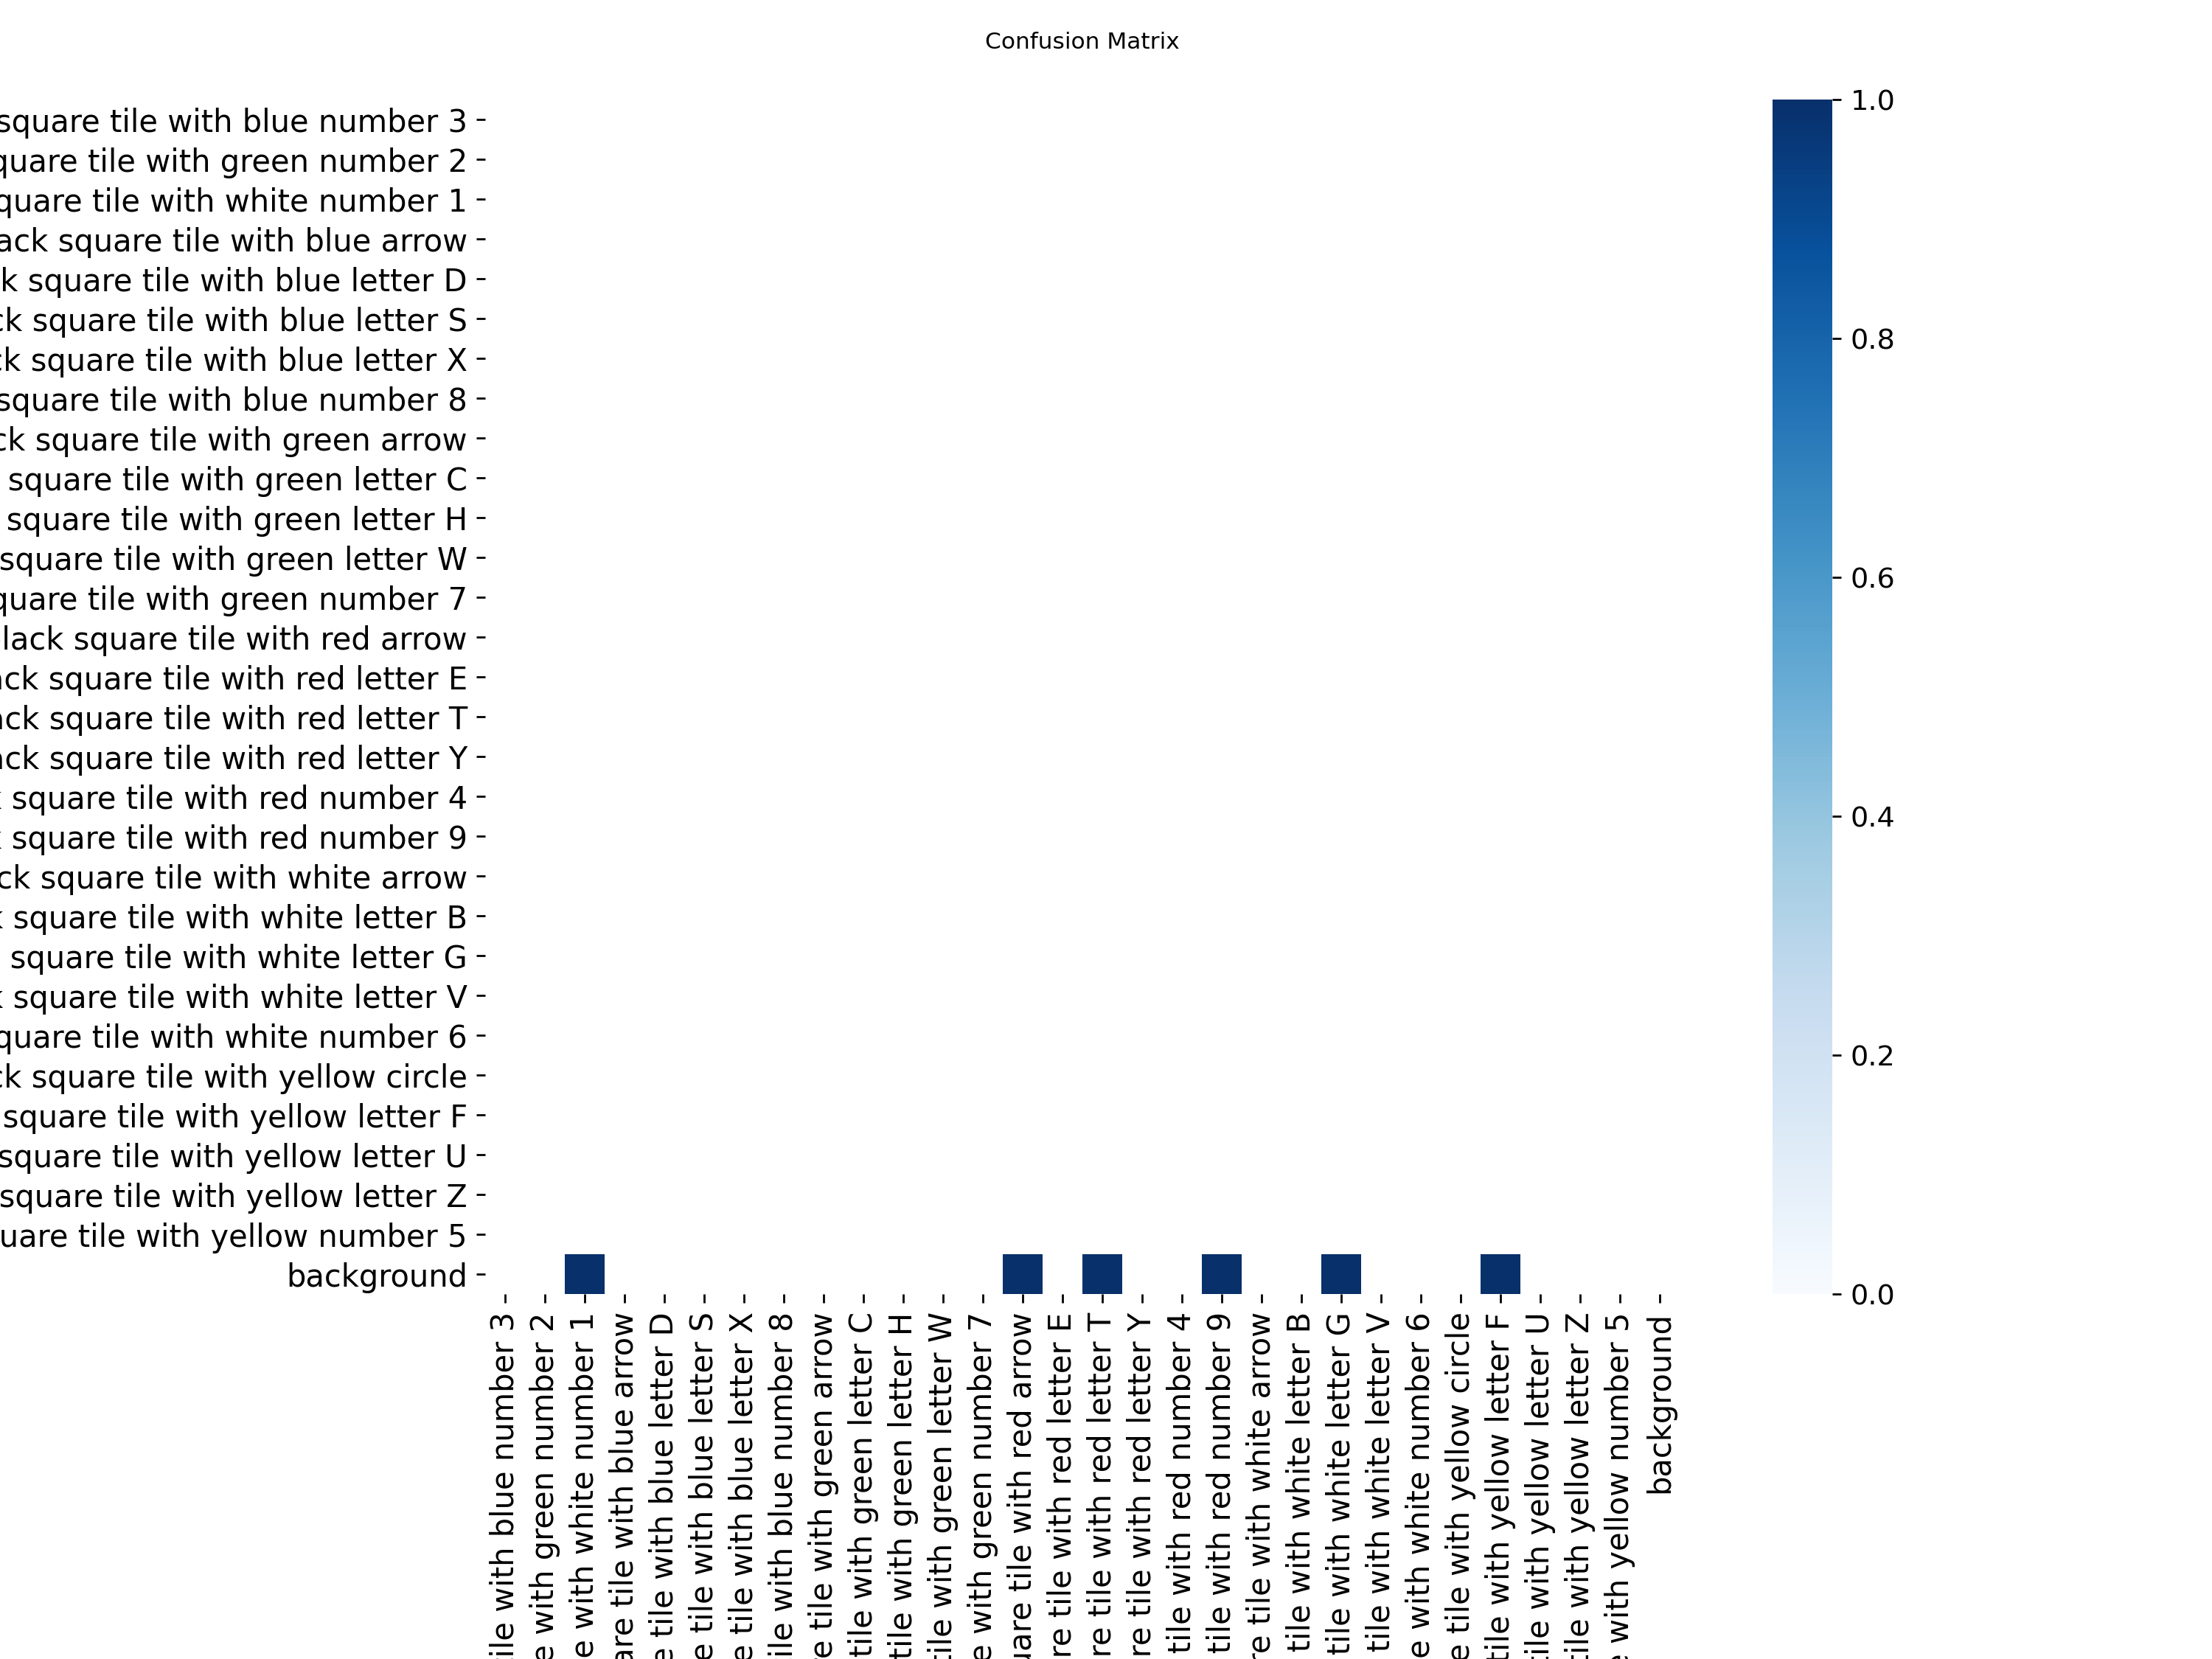

In [6]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="runs/detect/baseline/confusion_matrix.png"))

In [7]:
from roboflow import Roboflow
rf2 = Roboflow(api_key="RjXxbafrEGCh3xKidMhQ")
project2 = rf2.workspace("h-i-be7dk").project("object-detection-eynhl")
version2 = project2.version(2)
dataset_aug = version2.download("yolov8")
print(dataset_aug.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Object-Detection-2 in yolov8:: 100%|██████████| 89/89 [00:00<00:00, 5933.57it/s]

/content/Object-Detection-2


In [8]:
model_aug = YOLO("yolo11n.pt")
start = time.time()
results_aug = model_aug.train(
    data=f"{dataset_aug.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="exp_augmentation"
)
print(f"Training time: {(time.time()-start)/60:.1f} min")

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Object-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_augmentation, nbs=64, nms=None, opse

In [9]:
metrics_aug = model_aug.val(data=f"{dataset_aug.location}/data.yaml", split="test")
print("mAP50:", metrics_aug.box.map50)
print("mAP50-95:", metrics_aug.box.map)
print("Precision:", metrics_aug.box.mp)
print("Recall:", metrics_aug.box.mr)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,587,807 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2494.4±694.0 MB/s, size: 124.5 KB)
val: Scanning /content/Object-Detection-2/test/labels... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 1.6Kit/s 0.0s
val: New cache created: /content/Object-Detection-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 17.1it/s 0.1s
                   all          3          3      0.361          1      0.663       0.58
black square tile with blue letter S          1          1      0.333          1      0.497      0.448
black square tile with green arrow          1          1       0.25          1      0.995      0.895
black square tile with white letter B          1          1        0.5          1      0.497      0.398
Speed: 0.5ms preprocess, 7

In [ ]:
# Cell 9 — short training run for comparison
model_short = YOLO("yolo11n.pt")
start = time.time()
results_short = model_short.train(
    data=f"{dataset.location}/data.yaml",
    epochs=15,
    imgsz=640,
    batch=8,
    name="exp_epochs15"
)
print(f"Training time: {(time.time()-start)/60:.1f} min")

metrics_short = model_short.val(data=f"{dataset.location}/data.yaml", split="test")
print("mAP50:", metrics_short.box.map50)
print("mAP50-95:", metrics_short.box.map)

Ultralytics 8.4.147 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Object-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_epochs15, nbs=64, nms=None, opset=No

In [10]:
# Cell 10 — same 50 epochs, bigger model
model_small = YOLO("yolo11s.pt")
start = time.time()
results_medium = model_small.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="exp_yolo11s"
)
print(f"Training time: {(time.time()-start)/60:.1f} min")

metrics_medium = model_small.val(data=f"{dataset.location}/data.yaml", split="test")
print("mAP50:", metrics_medium.box.map50)
print("mAP50-95:", metrics_medium.box.map)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Object-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_yolo11s, nbs=64, nms=None, opset=Non

In [11]:
import cv2, glob
from ultralytics import YOLO

best = YOLO("runs/detect/baseline/weights/best.pt")
test_imgs = glob.glob(f"{dataset.location}/test/images/*.jpg")[:3]  # pick a few

for i, path in enumerate(test_imgs):
    img = cv2.imread(path)
    scenarios = {
        "blur": cv2.GaussianBlur(img, (15,15), 0),
        "rotate": cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),
        "dark": cv2.convertScaleAbs(img, alpha=0.4, beta=0),
    }
    for name, im in scenarios.items():
        fname = f"scenario_{name}_{i}.jpg"
        cv2.imwrite(fname, im)
        best.predict(fname, save=True, conf=0.25)


image 1/1 /content/scenario_blur_0.jpg: 640x640 (no detections), 7.9ms
Speed: 0.9ms preprocess, 7.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/scenario_rotate_0.jpg: 640x640 (no detections), 7.9ms
Speed: 0.9ms preprocess, 7.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/scenario_dark_0.jpg: 640x640 (no detections), 8.0ms
Speed: 0.8ms preprocess, 8.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/scenario_blur_1.jpg: 640x640 (no detections), 10.0ms
Speed: 0.9ms preprocess, 10.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

image 1/1 /content/scenario_rotate_1.jpg: 640x640 (no detections), 8.0ms
Speed: 0.9ms preprocess, 8.0ms inference, 0.6ms postprocess per im

In [12]:
from google.colab import files
files.download("runs/detect/baseline/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>